In [2]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import numpy as np

In [3]:
news_df = pd.read_csv("data/processed_news_data.csv")  # Dataset with keyword counts
crimes_df = pd.read_csv("data/crimes_number.csv")  # Dataset with crime counts

# Convert dates to datetime format
news_df["Дата"] = pd.to_datetime(news_df["Дата"])
crimes_df["Date"] = pd.to_datetime(crimes_df["Date"], format="%Y-%m")

# Convert dates to 'YYYY-MM' format
news_df["Дата"] = news_df["Дата"].dt.to_period("M")
crimes_df["Date"] = crimes_df["Date"].dt.to_period("M")

# Merge datasets by the date column
df = pd.merge(news_df, crimes_df, left_on="Дата", right_on="Date", how="inner")

# Remove duplicate date column if necessary
df.drop(columns=["Дата"], inplace=True)

# Translate keywords to english
column_translation = {
    "коррупция": "corruption",
    "взятка": "bribe",
    "приговор": "verdict",
    "хищение": "embezzlement",
    "расследование": "investigation",
    "задержание": "detention",
    "доллар": "dollar",
    "миллион": "million",
    "миллиард": "billion",
    "агентство": "agency",
    "преступление": "crime",
    "суд": "court",
    "министерство": "ministry",
    "аким": "akim",
    "начальник": "chief",
    "заместитель": "deputy",
    "район": "district",
    "город": "city",
    "область": "region",
    "правонарушение": "offense",
}

df.rename(columns=column_translation, inplace=True)

df['Date'] = df['Date'].dt.to_timestamp('s').dt.strftime('%Y-%m-%d')
df["Date"] = pd.to_datetime(df["Date"])
df['Month'] = pd.to_datetime(df['Date']).dt.month
df['Year'] = pd.to_datetime(df['Date']).dt.year

# Time-step feature

In [4]:
df_time_step = df.copy()
df_time_step["Time"] = np.arange(len(df.index))
df_time_step.head()

,corruption,bribe,verdict,embezzlement,investigation,detention,dollar,million,billion,agency,...,deputy,district,city,region,offense,Date,Total Crimes,Month,Year,Time
0,54,76.0,6.0,10.0,15.0,20.0,16.0,35.0,6.0,40.0,...,17.0,6.0,5.0,32.0,7.0,2016-11-01,3463.0,11,2016,0
1,40,24.0,2.0,4.0,11.0,7.0,3.0,15.0,1.0,24.0,...,9.0,4.0,3.0,14.0,6.0,2016-12-01,3214.0,12,2016,1
2,41,29.0,1.0,1.0,14.0,16.0,4.0,13.0,7.0,7.0,...,16.0,13.0,3.0,14.0,2.0,2017-01-01,1137.0,1,2017,2
3,24,16.0,15.0,19.0,16.0,10.0,18.0,40.0,11.0,5.0,...,3.0,3.0,9.0,14.0,3.0,2017-02-01,1337.0,2,2017,3
4,33,26.0,10.0,24.0,26.0,8.0,8.0,45.0,12.0,8.0,...,18.0,17.0,12.0,23.0,7.0,2017-03-01,1566.0,3,2017,4


Text(0.5, 1.0, 'Time Plot of Corruption Crimes')

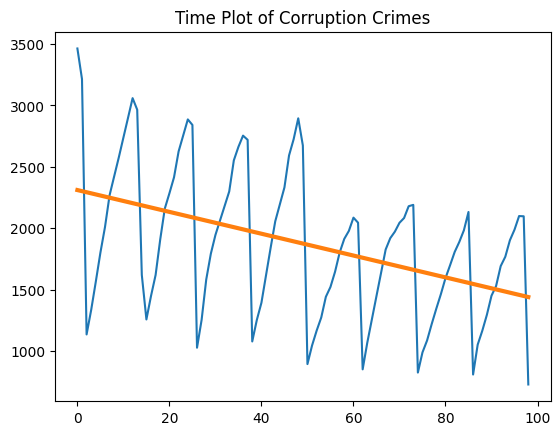

In [5]:
from sklearn.linear_model import LinearRegression


# Training data
X = df_time_step.loc[:, ["Time"]] # feature
y = df_time_step.loc[:, "Total Crimes"] # target

# Train model
model = LinearRegression()
model.fit(X, y)

y_pred = pd.Series(model.predict(X), index=X.index)

ax = y.plot()
ax = y_pred.plot(ax=ax, linewidth=3)
ax.set_title('Time Plot of Corruption Crimes')

# Lag plot

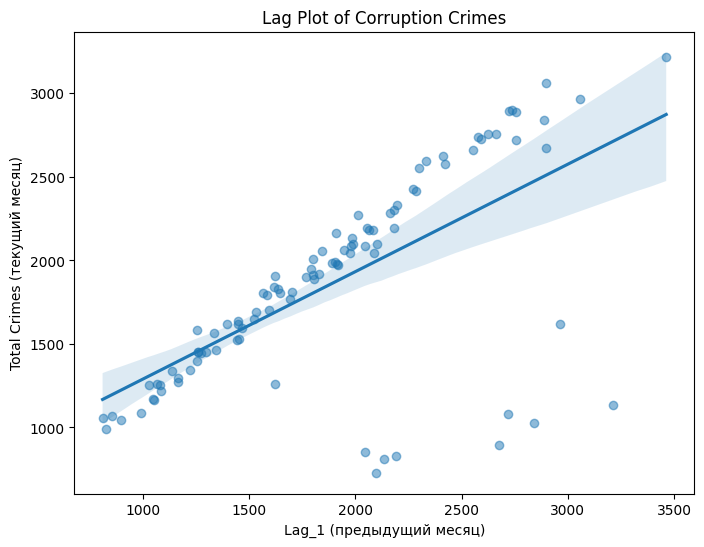

In [6]:
df_lag = df.sort_values("Date").copy()

# Создание лаг-признака
df_lag["Lag_1"] = df_lag["Total Crimes"].shift(1)

# Удаление первой строки (там будет NaN в Lag_1)
df_lag = df_lag.dropna()

# Построение лаг-графика
plt.figure(figsize=(8, 6))
sns.regplot(x=df_lag["Lag_1"], y=df_lag["Total Crimes"], scatter_kws={"alpha": 0.5})
plt.xlabel("Lag_1 (предыдущий месяц)")
plt.ylabel("Total Crimes (текущий месяц)")
plt.title("Lag Plot of Corruption Crimes")
plt.show()

# Оценка коэффициента weight с помощью линейной регрессии

In [7]:
import statsmodels.api as sm

# Загружаем данные
df_weight = df[['Month', 'Year', 'Total Crimes']].copy()

# Создаем лаговую переменную (предыдущий месяц)
df_weight['Lag_1'] = df_weight['Total Crimes'].shift(1)

# Удаляем первую строку (там будет NaN из-за сдвига)
df_weight = df_weight.dropna()

# Определяем переменные
X = df_weight['Lag_1']  # Признак (предыдущий месяц)
y = df_weight['Total Crimes']  # Целевая переменная (текущий месяц)

# Добавляем константу для регрессии
X = sm.add_constant(X)

# Обучаем модель
model = sm.OLS(y, X).fit()

# Выводим результаты
print(model.summary())


                            OLS Regression Results                            
Dep. Variable:           Total Crimes   R-squared:                       0.428
Model:                            OLS   Adj. R-squared:                  0.422
Method:                 Least Squares   F-statistic:                     71.84
Date:                Mon, 24 Mar 2025   Prob (F-statistic):           2.77e-13
Time:                        12:11:30   Log-Likelihood:                -737.85
No. Observations:                  98   AIC:                             1480.
Df Residuals:                      96   BIC:                             1485.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        645.9822    150.445      4.294      0.0

Давай разберем результаты регрессии:

Intercept (const):
Значение ≈ 645.98 – это базовый уровень количества преступлений, когда значение лаговой переменной равно 0. То есть, если в предыдущем месяце преступлений не было, модель предсказывает около 646 преступлений.

Коэффициент при Lag_1:
Значение ≈ 0.6431 говорит о том, что увеличение количества преступлений в предыдущем месяце на 1 единицу соответствует увеличению текущего месяца примерно на 0.64 единицы. Это указывает на положительную автокорреляцию: если в прошлом месяце было больше преступлений, то, как правило, и в текущем месяце их будет больше.

R-squared ≈ 0.428:
Модель объясняет примерно 42.8% вариации целевого признака. Это означает, что лаг-1 объясняет около 43% изменений в количестве преступлений. Остальная вариация определяется другими факторами, не включенными в модель.

Статистическая значимость:

P-value для константы и коэффициента при Lag_1 очень маленькие (P<0.001), что говорит о том, что оба параметра статистически значимы.

F-статистика также высока, и Prob(F-statistic) ≈ 2.77e-13 подтверждает, что модель в целом значима.

Дополнительные показатели:

Durbin-Watson (≈1.641): Этот показатель позволяет оценить автокорреляцию остатков. Значение немного отклоняется от идеального 2, что может указывать на некоторую положительную автокорреляцию остатков.

Condition number (≈6490): Очень высокое значение может указывать на потенциальные проблемы с мультиколлинеарностью или числовую нестабильность, хотя в модели с одним признаком это не столь критично.

Вывод:
Полученный коэффициент Lag_1 ≈ 0.6431 указывает на значительную положительную зависимость текущего значения от предыдущего. Это подтверждает, что в ряду присутствует serial dependence, и предыдущие значения являются хорошим предиктором для будущих. Если ты хочешь улучшить модель, можно рассмотреть включение дополнительных лагов или других признаков.

# Trend: Moving average plot

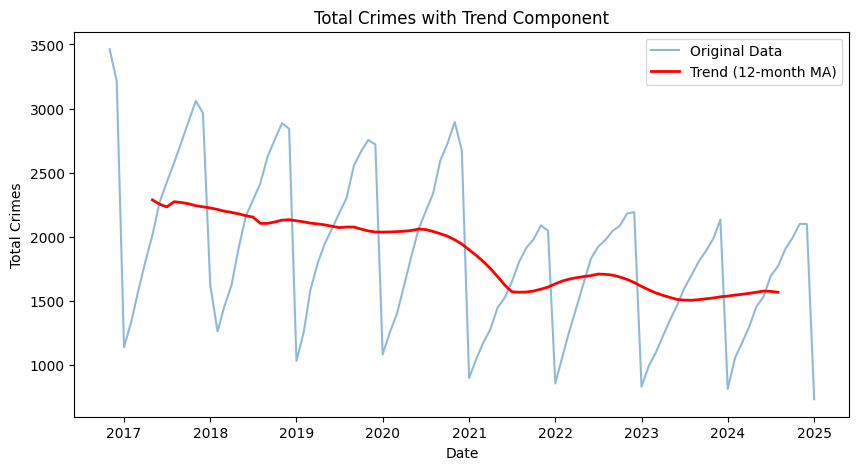

In [8]:
df_moving_avg = df[["Date", "Total Crimes"]].copy()

# Считаем скользящее среднее на 12 месяцев (год)
df_moving_avg['trend'] = df_moving_avg['Total Crimes'].rolling(window=12, center=True).mean()

# df_moving_avg['trend'] = df_moving_avg['trend'].interpolate().ffill().bfill()

# Построение графика
plt.figure(figsize=(10, 5))

# График исходных данных
plt.plot(df_moving_avg['Date'], df_moving_avg['Total Crimes'], label='Original Data', alpha=0.5)

# График тренда
plt.plot(df_moving_avg['Date'], df_moving_avg['trend'], label='Trend (12-month MA)', color='red', linewidth=2)

plt.xlabel('Date')
plt.ylabel('Total Crimes')
plt.title('Total Crimes with Trend Component')
plt.legend()
plt.show()

### Trend: Модуль DeterministicProcess из statsmodels.tsa.deterministic упрощает создание временных признаков (time-step features), чтобы включать тренд, сезонность и т.д. в регрессионную модель.

In [9]:
from statsmodels.tsa.deterministic import DeterministicProcess

df_dp = df[["Date", "Total Crimes"]].copy()
df_dp = df_dp.set_index("Date")

# 1) Создаем объект DeterministicProcess
dp = DeterministicProcess(
    index=df_dp.index,       # Индекс с временными метками
    order=1,              # Порядок полиномиального тренда (1 = линейный)
    seasonal=True,        # Включать ли сезонность
    period=12,            # Период сезонности (12 для месячных данных, 7 для дневных и т.д.)
    drop=True             # Удалять ли избыточные признаки (например, один из сезонных «манекенов»)
)

# 2) Генерируем матрицу признаков для "in-sample" (т.е. по тем датам, что у нас есть)
X = dp.in_sample()

# 3) Обучаем модель на полученных признаках
y = df_dp['Total Crimes']  # Наша целевая переменная
X = sm.add_constant(X)  # Добавляем константу, если нужно
model = sm.OLS(y, X).fit()

print(model.summary())

# 4) Если хотим прогнозировать на будущее, генерируем "out-of-sample" признаки
# Предположим, хотим еще 12 шагов вперёд
X_future = dp.out_of_sample(steps=12)
X_future = sm.add_constant(X_future, has_constant='add')

y_forecast = model.predict(X_future)
print(y_forecast)

                            OLS Regression Results                            
Dep. Variable:           Total Crimes   R-squared:                       0.931
Model:                            OLS   Adj. R-squared:                  0.922
Method:                 Least Squares   F-statistic:                     97.17
Date:                Mon, 24 Mar 2025   Prob (F-statistic):           1.17e-44
Time:                        12:11:31   Log-Likelihood:                -643.45
No. Observations:                  99   AIC:                             1313.
Df Residuals:                      86   BIC:                             1347.
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       2173.2510     32.354     67.170      0.0

c:\Users\asanb\.pyenv\pyenv-win\versions\3.13.1\Lib\site-packages\statsmodels\tsa\deterministic.py:308: UserWarning: Only PeriodIndexes, DatetimeIndexes with a frequency set, RangesIndexes, and Index with a unit increment support extending. The index is set will contain the position relative to the data length.
  fcast_index = self._extend_index(index, steps, forecast_index)
c:\Users\asanb\.pyenv\pyenv-win\versions\3.13.1\Lib\site-packages\statsmodels\tsa\deterministic.py:441: UserWarning: Only PeriodIndexes, DatetimeIndexes with a frequency set, RangesIndexes, and Index with a unit increment support extending. The index is set will contain the position relative to the data length.
  fcast_index = self._extend_index(index, steps, forecast_index)


Давайте разберем ключевые моменты результата регрессии:

Общая характеристика модели:

R-squared = 0.931 и Adj. R-squared = 0.922:
Модель объясняет около 93% вариации в переменной "Total Crimes". Это означает, что использованные признаки (тренд и сезонные компоненты) очень хорошо описывают изменения в целевой переменной.

Параметры модели:

const = 2173.2510:
Это базовый уровень количества преступлений, когда все другие признаки равны нулю.

trend = -9.6676:
Коэффициент при трендовом признаке показывает, что при увеличении времени на один шаг, при условии, что сезонные эффекты остаются неизменными, количество преступлений уменьшается примерно на 9.67 единиц.

Сезонные компоненты (s(1,12), s(2,12), ...):
Эти коэффициенты отражают сезонные отклонения. Например, s(1,12) равное ≈901.35 говорит о том, что в соответствующий период (например, январь, если s(1,12) соответствует первому месяцу года) наблюдается повышение на этот объем по сравнению с базовой категорией. Аналогично, отрицательные коэффициенты (например, s(3,12) ≈ -682) указывают на период, когда значения ниже базового уровня.

Статистическая значимость:

Все коэффициенты, включая тренд и сезонные компоненты, имеют очень маленькие p-value (p < 0.001 для большинства), что говорит о том, что они статистически значимы и их влияние на целевую переменную подтверждено данными.

Модель и прогнозирование:

Используя DeterministicProcess, вы смогли включить в модель как трендовую составляющую, так и сезонность (с периодом 12, что соответствует годовой сезонности для месячных данных).

Если в конце отчета (строки с номерами 109, 110, 111) приведены прогнозные значения, то модель также успешно сгенерировала предсказания для будущих периодов на основе полученных коэффициентов.

Таким образом, модель демонстрирует, что в ряду "Total Crimes" присутствует явная сезонная динамика, а также устойчивый тренд (в данном случае отрицательный). Такой подход позволяет более точно предсказывать будущие значения, учитывая как долгосрочную тенденцию, так и регулярные сезонные колебания.

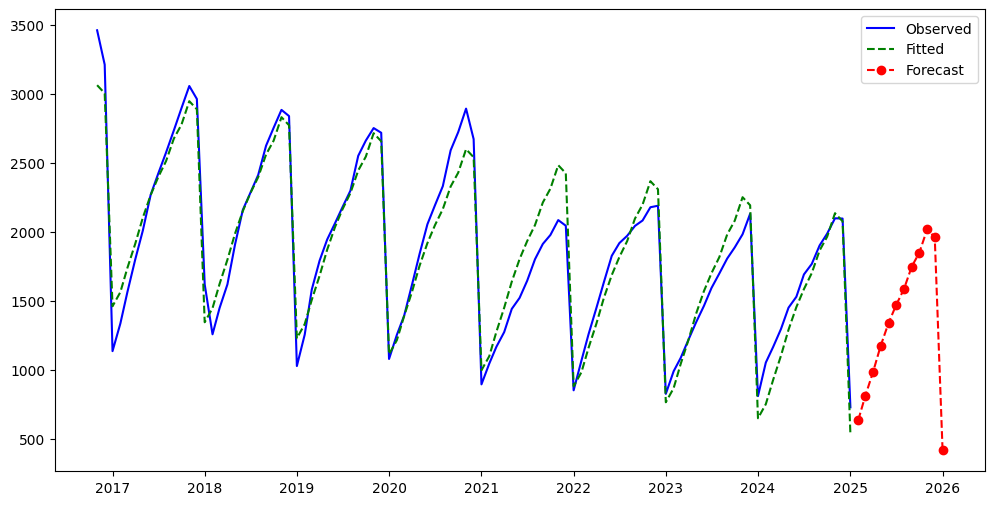

In [10]:
# Предположим, у вас месячные данные
df_dp = df_dp.sort_index()

# Устанавливаем частоту (если пропущены месяцы, могут быть NaN)
df_dp = df_dp.asfreq('MS')

dp = DeterministicProcess(
    index=df_dp.index,    
    order=1,           
    seasonal=True,     
    period=12,         
    drop=True          
)

X = dp.in_sample()
y = df_dp['Total Crimes']

X = sm.add_constant(X)
model = sm.OLS(y, X).fit()

# Прогноз на 12 шагов вперёд
X_future = dp.out_of_sample(steps=12)
X_future = sm.add_constant(X_future, has_constant='add')
y_forecast = model.predict(X_future)

plt.figure(figsize=(12, 6))
plt.plot(df_dp.index, y, label="Observed", color='blue')
plt.plot(df_dp.index, model.predict(X), label="Fitted", linestyle='--', color='green')
plt.plot(X_future.index, y_forecast, label="Forecast", linestyle='--', marker='o', color='red')
plt.legend()
plt.show()


Судя по графику, у тебя теперь корректно отобразились:

Observed (синие точки/линия) — реальные данные

Fitted (зелёная пунктирная линия) — подогнанная модель на исторических данных

Forecast (красные точки) — прогноз на несколько периодов вперёд

Почему прогноз может резко снижаться:

Негативный тренд. В результатах регрессии был отрицательный коэффициент при trend. Это значит, что модель «видит» общую тенденцию к уменьшению и продолжает её экстраполировать в будущее.

Сезонность. Если последние месяцы в ряду обычно показывали спад (например, это могут быть периоды года с низкими значениями), то модель будет ожидать повторения такого паттерна.

Чтобы понять, насколько такой прогноз реалистичен:

Проверь, нет ли выбросов или пропущенных значений в конце ряда, которые могли повлиять на оценку модели.

Попробуй изменить порядок тренда (например, order=2), если визуально тренд кажется нелинейным.

Проверь, что период сезонности (12 месяцев) действительно отражает все циклы в данных. Иногда, помимо годовой сезонности, могут быть другие циклы.

Если нужно более «гибкое» моделирование (учитывающее не только линейный тренд и сезонность), можно рассмотреть:

SARIMA (Seasonal ARIMA),

Prophet (библиотека Facebook Prophet),

neuralprophet,

или более продвинутые модели машинного обучения (LightGBM, RandomForest) с ручной генерацией временных признаков.

Но, в целом, твой график уже хорошо показывает, как линейная модель с сезонностью (DeterministicProcess) описывает данные и делает прогноз.

## Seasonality: Seasonal plot

                            OLS Regression Results                            
Dep. Variable:           Total Crimes   R-squared:                       0.931
Model:                            OLS   Adj. R-squared:                  0.922
Method:                 Least Squares   F-statistic:                     97.17
Date:                Mon, 24 Mar 2025   Prob (F-statistic):           1.17e-44
Time:                        12:11:31   Log-Likelihood:                -643.45
No. Observations:                  99   AIC:                             1313.
Df Residuals:                      86   BIC:                             1347.
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       1491.2717     65.378     22.810      0.0

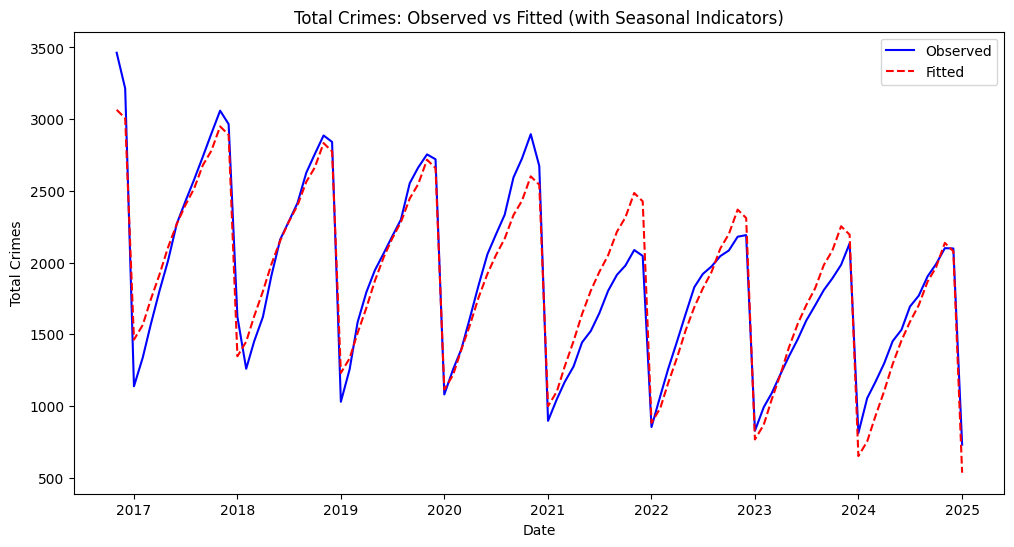

In [11]:
df_sp = df[["Date", "Month", "Total Crimes"]].copy()

# Создаем сезонные индикаторы с помощью one-hot encoding
# drop_first=True, чтобы избежать мультиколлинеарности (одна из категорий станет базовой)
seasonal_dummies = pd.get_dummies(df_sp['Month'], prefix='month', drop_first=True)

# Объединяем исходный DataFrame с бинарными признаками
df_seasonal = pd.concat([df_sp, seasonal_dummies], axis=1)

# Добавляем трендовую переменную (например, порядковый номер наблюдения)
df_seasonal['trend'] = range(1, len(df_seasonal) + 1)

# Определяем признаки для модели: тренд + сезонные индикаторы
X = df_seasonal[['trend'] + list(seasonal_dummies.columns)]
y = df_seasonal['Total Crimes']

# Добавляем константу для модели
X = sm.add_constant(X)

# Приведем все столбцы X к типу float
X = X.astype(float)

# Обучаем модель линейной регрессии
model = sm.OLS(y, X).fit()

# Выводим сводку модели
print(model.summary())

# Можно построить график подогнанных значений
df_seasonal['fitted'] = model.predict(X)

plt.figure(figsize=(12, 6))
plt.plot(df_seasonal['Date'], y, label="Observed", color='blue')
plt.plot(df_seasonal['Date'], df_seasonal['fitted'], label="Fitted", linestyle='--', color='red')
plt.xlabel("Date")
plt.ylabel("Total Crimes")
plt.title("Total Crimes: Observed vs Fitted (with Seasonal Indicators)")
plt.legend()
plt.show()

Отлично! Судя по графику и статистике, у модели хорошее приближение (R² ≈ 0.918). Значит, использование сезонных индикаторов вместе с трендом хорошо описывает ваши данные.

Что ещё можно попробовать?
Проверить остатки (residuals)

Построить график остатков во времени, гистограмму или qq-plot. Если остатки распределены случайно и не показывают систематических паттернов, значит, модель хорошо справляется.

Если видна дополнительная структура (например, волнообразный рисунок или тренд в остатках), возможно, в данных есть ещё какая-то цикличность, которую не учли.

Добавить дополнительные лаги

Если есть предположение, что прошлые значения (например, предыдущий месяц) влияют на текущий уровень, можно добавить лаговые признаки.

Уточнить частоту сезонности

Сейчас вы используете сезонные индикаторы для месяцев. Если в данных может быть более сложная сезонность (например, квартальная или недельная), можно расширить модель, но обычно месячной сезонности достаточно.

Перейти к более сложным моделям

Если сезонные индикаторы и тренд не полностью объясняют динамику, можно попробовать SARIMA, Prophet, или модели машинного обучения (Random Forest, LightGBM) с дополнительными временными признаками.

Проверить мультиколлинеарность

Часто бывает, что тренд и сезонные признаки могут быть скоррелированы. Можно посмотреть на значения VIF (Variance Inflation Factor) или просто посмотреть на корреляцию признаков. Если мультиколлинеарность высока, в некоторых случаях это может ухудшить интерпретацию модели.

Но в целом, если основной целью было учесть тренд и сезонность, то текущее решение уже выглядит вполне удачным.

## Seasonality: Fourier Features

                            OLS Regression Results                            
Dep. Variable:           Total Crimes   R-squared:                       0.864
Model:                            OLS   Adj. R-squared:                  0.854
Method:                 Least Squares   F-statistic:                     82.86
Date:                Mon, 24 Mar 2025   Prob (F-statistic):           1.07e-36
Time:                        12:11:31   Log-Likelihood:                -677.13
No. Observations:                  99   AIC:                             1370.
Df Residuals:                      91   BIC:                             1391.
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       2347.3321     47.138     49.797      0.0

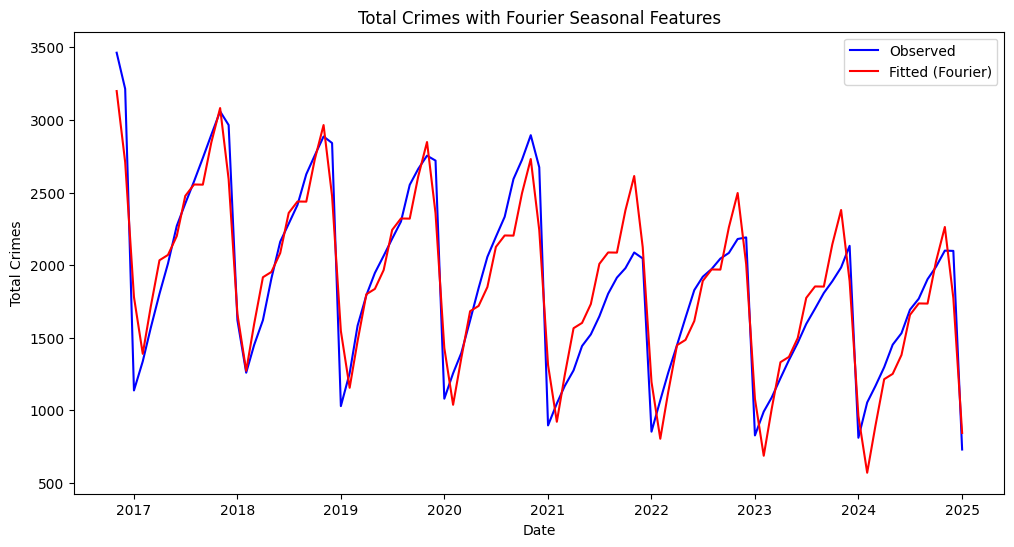

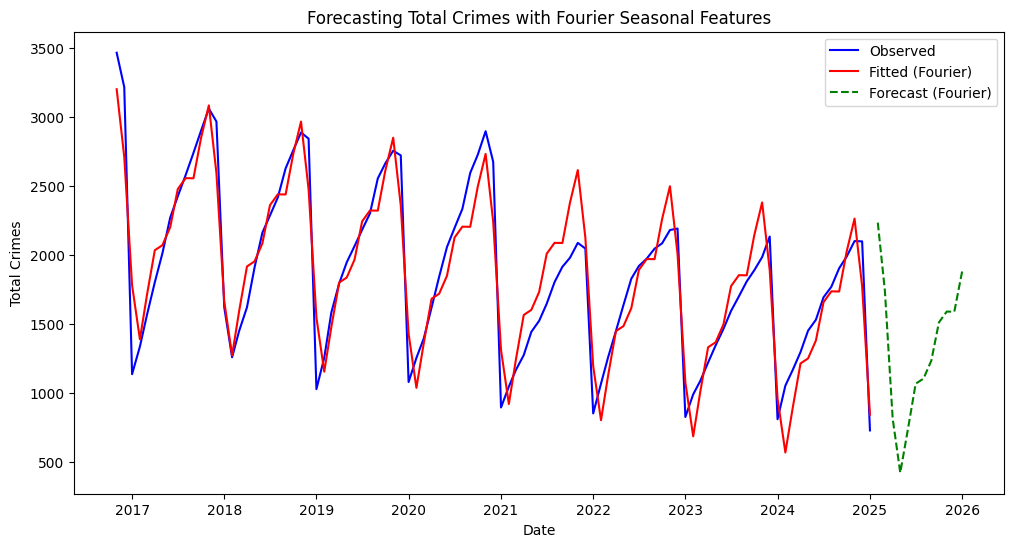

In [12]:
df_fourier = df[["Date", "Total Crimes"]].copy()
df_fourier = df_fourier.sort_values("Date")
df_fourier = df_fourier.set_index("Date")
df_fourier = df_fourier.asfreq("MS")

y = df_fourier["Total Crimes"]

def fourier_features(index, period, K):
    """
    Создает 2*K Fourier-признаков (синус/косинус) для заданного DatetimeIndex.
    
    index  : DatetimeIndex
    period : Период сезонности (12 для месячных данных, 365 для дневных)
    K      : Количество гармоник
    """
    t = np.arange(len(index))
    # Преобразуем период в "количество шагов" (для месячных = 12, для дневных = 365)
    # Формула для омега = 2*pi / period
    w = 2 * np.pi / period
    
    # Словарь для хранения признаков
    data = {}
    for k in range(1, K+1):
        data[f'sin_{k}'] = np.sin(k * w * t)
        data[f'cos_{k}'] = np.cos(k * w * t)
    
    return pd.DataFrame(data, index=index)

# Выбираем, к примеру, 12-месячную сезонность и 3 гармоники
period = 12  
K = 3

X_fourier = fourier_features(df_fourier.index, period=period, K=K)

# Линейный тренд: порядковый номер наблюдения
X_fourier['trend'] = range(len(X_fourier))

# Добавляем константу
X_fourier = sm.add_constant(X_fourier)

# Удаляем возможные NaN (если есть пропуски в данных)
y = y.dropna()
X_fourier = X_fourier.loc[y.index].dropna()

# Обучаем модель линейной регрессии (OLS)
model = sm.OLS(y, X_fourier).fit()
print(model.summary())

df_fourier['fitted_fourier'] = model.predict(X_fourier)

plt.figure(figsize=(12,6))
plt.plot(df_fourier.index, df_fourier['Total Crimes'], label='Observed', color='blue')
plt.plot(df_fourier.index, df_fourier['fitted_fourier'], label='Fitted (Fourier)', color='red')
plt.xlabel('Date')
plt.ylabel('Total Crimes')
plt.title('Total Crimes with Fourier Seasonal Features')
plt.legend()
plt.show()

# Создадим будущие даты
future_index = pd.date_range(start=df_fourier.index[-1] + pd.offsets.MonthBegin(1), 
                             periods=12, 
                             freq='MS')

# Сгенерируем Fourier-признаки для будущих дат
X_future = fourier_features(future_index, period=period, K=K)

# Добавим тренд (продолжим нумерацию)
last_trend = X_fourier['trend'].iloc[-1]
X_future['trend'] = range(last_trend + 1, last_trend + 1 + len(X_future))

# Добавим константу
X_future = sm.add_constant(X_future, has_constant='add')

# Прогноз
y_future = model.predict(X_future)

# График
plt.figure(figsize=(12,6))
plt.plot(df_fourier.index, df_fourier['Total Crimes'], label='Observed', color='blue')
plt.plot(df_fourier.index, df_fourier['fitted_fourier'], label='Fitted (Fourier)', color='red')
plt.plot(future_index, y_future, label='Forecast (Fourier)', color='green', linestyle='--')
plt.xlabel('Date')
plt.ylabel('Total Crimes')
plt.title('Forecasting Total Crimes with Fourier Seasonal Features')
plt.legend()
plt.show()


Судя по сводке, модель с Fourier-признаками (3 гармоники) и линейным трендом даёт:

R-squared ≈ 0.864

Модель объясняет около 86% вариации целевой переменной.

Это несколько ниже, чем в случае с сезонными индикаторами (где было ~0.918), но всё ещё довольно высокий показатель.

Сезонные компоненты (sin_k и cos_k):

sin
⁡
1
sin 
1
​
  и 
cos
⁡
1
cos 
1
​
  имеют самые большие и статистически значимые коэффициенты. Это логично, так как они описывают «основную волну» (с частотой 1 цикл в год).

sin
⁡
2
sin 
2
​
  оказался незначим (p-value ~ 0.68), тогда как 
cos
⁡
2
cos 
2
​
  — наоборот, значим. Это говорит, что вторая гармоника (2 цикла в год) может быть слабо выражена в синусной фазе, но заметна в косинусной.

sin
⁡
3
sin 
3
​
  и 
cos
⁡
3
cos 
3
​
  тоже оказались значимы, значит в данных присутствуют колебания на частоте 3 цикла в год (примерно каждые 4 месяца).

Тренд:

Коэффициент 
−
9.7519
−9.7519 при trend говорит о том, что, согласно модели, есть устойчивое снижение на ~9.75 единиц за каждый дополнительный шаг времени (месяц, если индекс у вас месячный).

Если это интерпретировать буквально: с каждым месяцем «базовый уровень» уменьшается примерно на 10 преступлений.

Что можно сделать дальше?

Оценить график остатков (residuals) — посмотреть, нет ли в них структуры, не учтённой моделью.

Убрать незначимые гармоники. Например, раз 
sin
⁡
2
sin 
2
​
  имеет p-value 0.68, можно попробовать исключить его из модели и посмотреть, улучшится ли качество.

Изменить число гармоник (K). Если годовая сезонность сложная, можно увеличить K, но есть риск переобучения. Если сезонность более простая, можно уменьшить K.

Сравнить с моделью на сезонных индикаторах. Вы уже видите, что модель с бинарными индикаторами показала R² ~0.918, тогда как здесь ~0.864. Возможно, для ваших данных индикаторы лучше описывают сезонность.

В итоге, Fourier-признаки дают гибкую аппроксимацию сезонности с помощью нескольких «волн». У вас получился неплохой результат, но чуть хуже, чем с индикаторами. Это может быть связано с тем, что ваша сезонность не просто гладкая волна, а может иметь резкие пики, которые индикаторы «ловят» лучше.

## Прикольный график

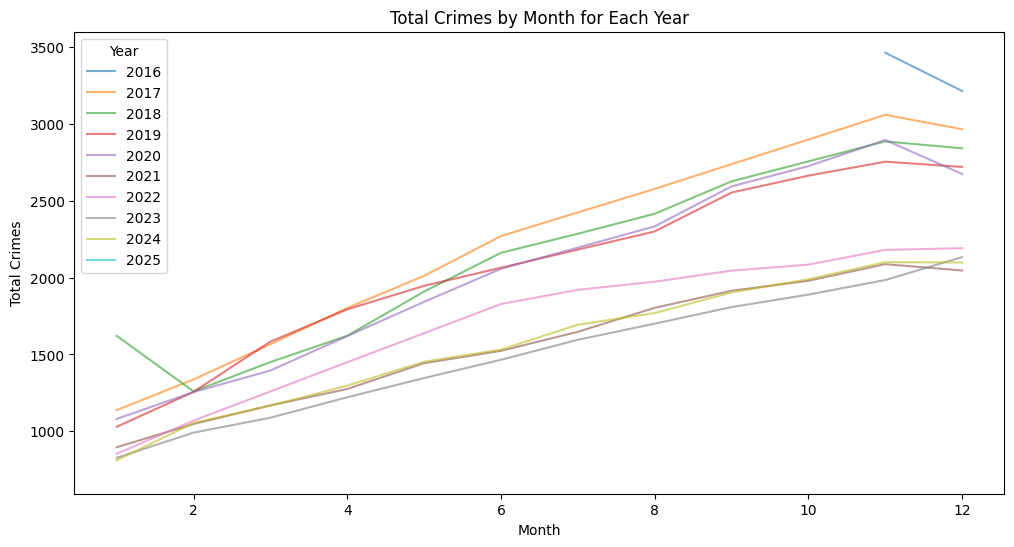

In [13]:
df_graph = df[["Date", "Total Crimes"]].copy()

df_graph['Date'] = pd.to_datetime(df_graph['Date'])
df_graph = df_graph.sort_values('Date')

# Создаем новые столбцы: год и день года
df_graph['year'] = df_graph['Date'].dt.year
df_graph['month'] = df_graph['Date'].dt.month
# df_graph['dayofyear'] = df_graph['Date'].dt.dayofyear

# Построение графика: для каждого года строим линию по дню года
plt.figure(figsize=(12, 6))
for year, group in df_graph.groupby('year'):
    # plt.plot(group['dayofyear'], group['Total Crimes'], label=str(year), alpha=0.6)
    plt.plot(group['month'], group['Total Crimes'], label=str(year), alpha=0.6)

plt.xlabel('Month')
plt.ylabel('Total Crimes')
plt.title('Total Crimes by Month for Each Year')
plt.legend(title="Year")
plt.show()

На Рисунке X показана динамика преступлений по месяцам для каждого года. Видно, что для всех лет кривые имеют монотонный рост от начала года (январь) к концу (декабрь). Это говорит о том, что количество зарегистрированных преступлений в течение года стабильно увеличивается. При этом для разных лет абсолютный уровень (начальные и конечные значения) может отличаться, но общая форма (низкие значения в начале года и высокие — в конце) сохраняется.

Подобное поведение может указывать на внутригодовую сезонность, когда минимумы приходятся на ранние месяцы, а максимумы — на последние. Возможные причины такой тенденции могут включать социально-экономические факторы, календарные особенности или оперативные особенности учёта преступлений (например, некоторые преступления фиксируются в конце года). Для точного объяснения стоит дополнительно изучить факторы, влияющие на распределение преступлений по месяцам.

Важные моменты:

Монотонный рост в течение года: может означать либо реальное накопление случаев, либо особенности учёта (в конце года собирают больше данных).

Различия по годам: амплитуда (начальный и конечный уровень) варьируется, что может указывать на общий тренд или внешние факторы, меняющиеся из года в год.

Сезонность: обычно подразумевает «волнообразное» поведение, но здесь мы видим именно «восходящую линию» — тоже вариант сезонной структуры, где «низкий сезон» в начале года и «высокий сезон» в конце.

Таким образом, график наглядно демонстрирует, что внутри одного календарного года преступления растут от месяца к месяцу, а сопоставление разных лет помогает увидеть общую динамику и сравнить уровни преступности между ними.

## Seasonality: Periodogram

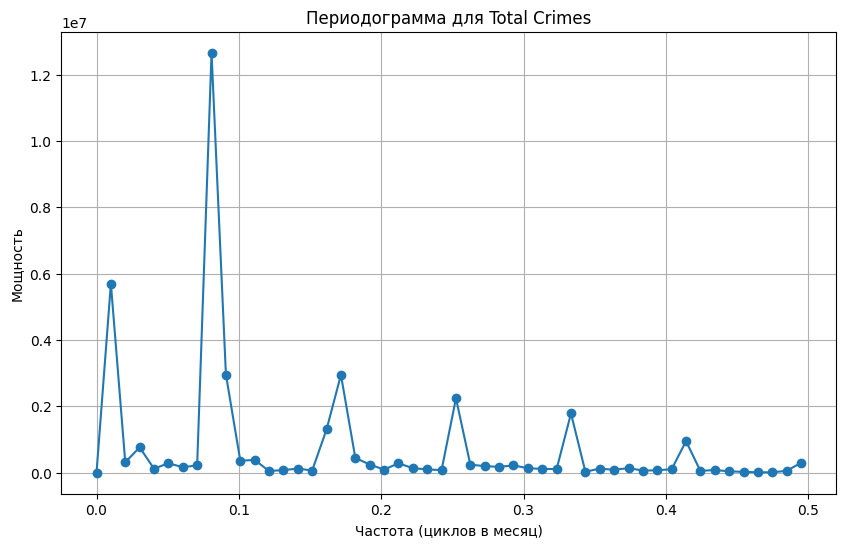

In [14]:
from scipy.signal import periodogram


df_periodogram = df[["Date", "Total Crimes"]].copy()
df_periodogram['Date'] = pd.to_datetime(df_periodogram['Date'])
df_periodogram = df_periodogram.sort_values('Date')
df_periodogram = df_periodogram.set_index('Date')

# Извлекаем временной ряд, удаляя пропуски
y = df_periodogram['Total Crimes'].dropna()

# Для месячных данных принимаем частоту дискретизации fs = 1 (один образец в месяц)
fs = 1

# Вычисляем периодограмму
frequencies, power = periodogram(y, fs=fs)

# Строим график периодограммы
plt.figure(figsize=(10,6))
plt.plot(frequencies, power, marker='o', linestyle='-')
plt.xlabel('Частота (циклов в месяц)')
plt.ylabel('Мощность')
plt.title('Периодограмма для Total Crimes')
plt.grid(True)
plt.show()

На периодограмме виден выраженный пик в районе частоты около 0.08 циклов в месяц. Если перевести это в период (количество месяцев на один цикл), получим:

Период ≈ $\frac{1}{0.08}$ = 12.5 месяцев.


Это близко к 12 месяцам, что говорит о годовой сезонности. То есть самые сильные колебания в ваших данных повторяются примерно раз в год.

Кроме того, можно заметить более мелкие пики на других частотах, но основной «сплеск» мощности именно возле 
0.08
0.08. Это подтверждает, что в данных присутствует явно выраженный годовой паттерн (сезонность), а остальные частоты вносят меньший вклад.

Если вы работаете с помесячными данными, этот результат согласуется с тем, что мы видели ранее: графики по месяцам показывают возрастание преступлений к концу года, и периодограмма указывает, что наиболее мощная волна в данных — это волна с периодом около года.


# Serial dependence

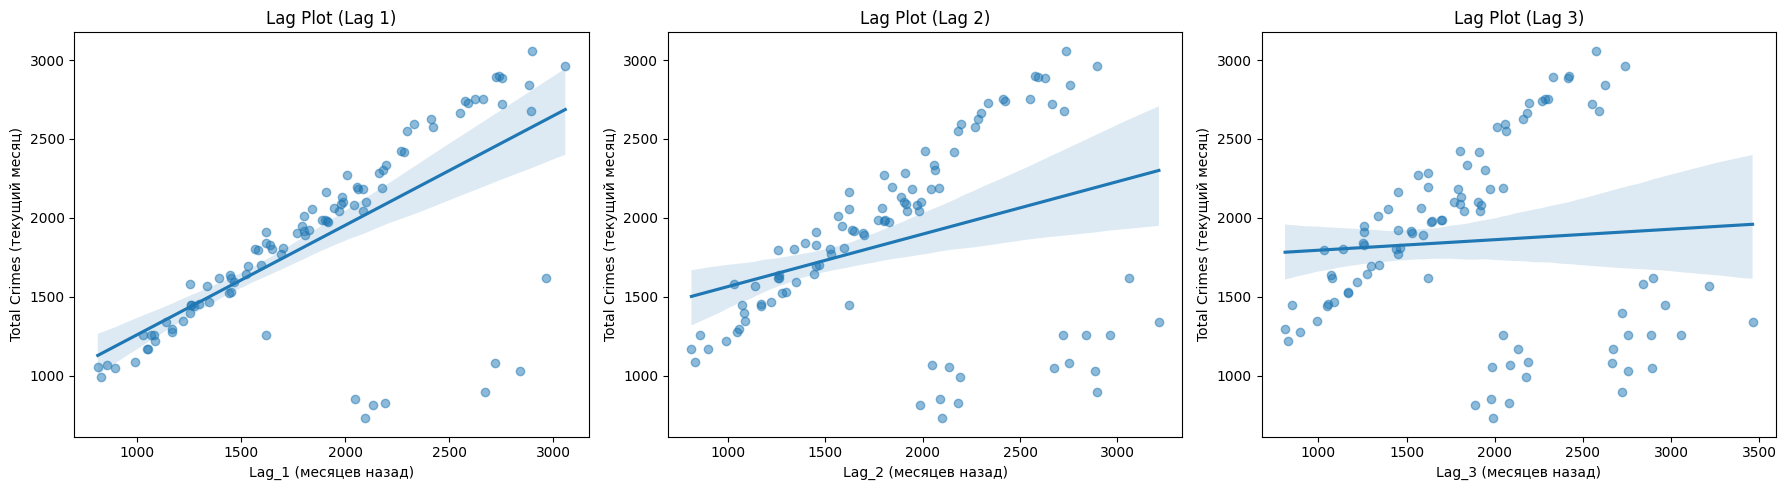

In [37]:
# Загружаем данные
df_sd = df[['Month', 'Year', 'Total Crimes']].copy()

# Создаем лаговую переменную (предыдущий месяц)
df_sd['Lag_1'] = df_sd['Total Crimes'].shift(1)
df_sd['Lag_2'] = df_sd['Total Crimes'].shift(2)
df_sd['Lag_3'] = df_sd['Total Crimes'].shift(3)

# Удаление первой строки (там будет NaN в Lag_1)
df_sd = df_sd.dropna()

# Создаем фигуру с 3 подграфиками
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Список лагов
lags = [1, 2, 3]

for i, lag in enumerate(lags):
    sns.regplot(x=df_sd[f"Lag_{lag}"], y=df_sd["Total Crimes"], scatter_kws={"alpha": 0.5}, ax=axes[i])
    axes[i].set_xlabel(f"Lag_{lag} (месяцев назад)")
    axes[i].set_ylabel("Total Crimes (текущий месяц)")
    axes[i].set_title(f"Lag Plot (Lag {lag})")

plt.tight_layout()
plt.show()

Судя по полученным графикам:

Lag_1: На первом графике (Lag 1) заметна выраженная положительная связь: если в предыдущем месяце преступлений было много, то и в текущем месяце их, скорее всего, тоже много. Линейная регрессия даёт хороший наклон вверх.

Lag_2: На втором графике (Lag 2) связь тоже положительная, но кажется менее выраженной и более «разбросанной». Линейная регрессия показывает положительный наклон, но доверительный интервал шире.

Lag_3: На третьем графике (Lag 3) связь практически горизонтальная: судя по регрессионной прямой, влияние значений трёх месяцев назад уже не столь заметно (или очень слабое).

Это говорит о том, что серийная зависимость (autocorrelation) сильнее проявляется между соседними месяцами (Lag_1), чем при большем лаге (Lag_2 или Lag_3).

In [38]:
df_sd

,Month,Year,Total Crimes,Lag_1,Lag_2,Lag_3
3,2,2017,1337.0,1137.0,3214.0,3463.0
4,3,2017,1566.0,1337.0,1137.0,3214.0
5,4,2017,1802.0,1566.0,1337.0,1137.0
6,5,2017,2011.0,1802.0,1566.0,1337.0
7,6,2017,2270.0,2011.0,1802.0,1566.0
...,...,...,...,...,...,...
94,9,2024,1903.0,1769.0,1693.0,1531.0
95,10,2024,1989.0,1903.0,1769.0,1693.0
96,11,2024,2100.0,1989.0,1903.0,1769.0
97,12,2024,2098.0,2100.0,1989.0,1903.0


## Partial autocorrelation

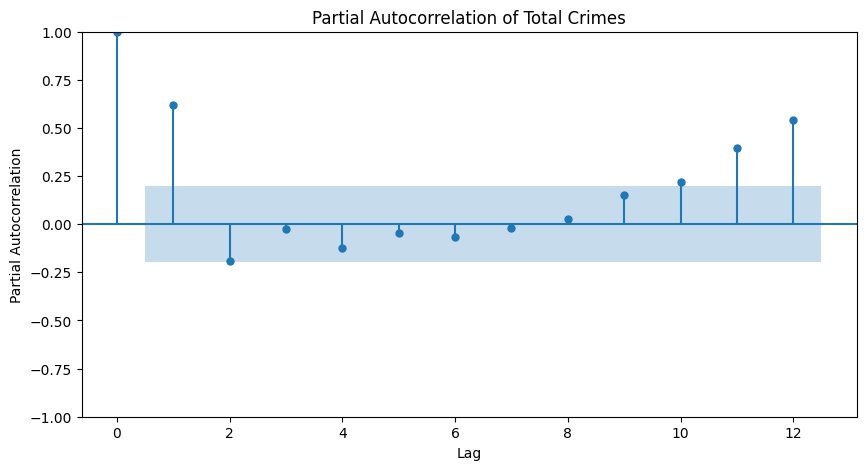

In [40]:
from statsmodels.graphics.tsaplots import plot_pacf

# Предполагается, что DataFrame df содержит колонки "Date" и "Total Crimes"
df_pacf = df[['Date', 'Total Crimes']].copy()

# Преобразуем дату и сортируем
df_pacf['Date'] = pd.to_datetime(df_pacf['Date'])
df_pacf = df_pacf.sort_values('Date').set_index('Date')

# Извлекаем сам временной ряд
y = df_pacf['Total Crimes'].dropna()

# Строим PACF
fig, ax = plt.subplots(figsize=(10, 5))
plot_pacf(y, ax=ax, method='ywm', lags=12)  # method='ywm' или 'ols' (какой предпочитаешь)
plt.xlabel('Lag')
plt.ylabel('Partial Autocorrelation')
plt.title('Partial Autocorrelation of Total Crimes')
plt.show()

Судя по графику частичной автокорреляции (PACF):

Лаг 1 сильно выходит за пределы доверительного интервала, причём положительно.

Это означает, что значение ряда в текущем месяце сильно зависит от значения в предыдущем месяце (после учёта других лагов).

Для лагов 2, 3 и дальше столбцы находятся в пределах синей зоны (доверительного интервала) или совсем незначительно выходят за её границы.

Это говорит, что прямое влияние более ранних значений (2 месяца назад, 3 месяца назад и т. д.) либо слабое, либо перекрывается эффектом от лаг-1.

Возможно, у лагов 11 или 12 есть небольшой всплеск, что иногда свидетельствует о годовой сезонности (если он статистически значим). Однако по графику кажется, что значения не так сильно выходят за доверительный интервал, как лаг 1.

На графике частичной автокорреляции (PACF) из statsmodels синим прямоугольником (или синими «полосами») отображается доверительный интервал вокруг нуля. Обычно это 
±
2
±2 стандартные ошибки.

Если столбец выходит за границы этого голубого диапазона, значит соответствующая частичная автокорреляция статистически значима, и можно говорить, что лаг вносит существенный вклад. Если же столбец «прячется» внутри синих границ, то с точки зрения статистики нет уверенности, что автокорреляция на этом лаге отличается от нуля.

# Hybrid models and residuals

## Residual plot

    Actual    Predicted   Residuals
1   1054.0   958.082321   95.917679
2   1167.0  1080.736042   86.263958
3   1297.0  1219.920264   77.079736
4   1452.0  1370.711688   81.288312
5   1531.0  1513.083165   17.916835
6   1693.0  1607.721513   85.278487
7   1769.0  1680.665822   88.334178
8   1903.0  1766.455586  136.544414
9   1989.0  1816.879387  172.120613
10  2100.0  1912.148114  187.851886
11  2098.0  1938.379817  159.620183
12   730.0   589.331929  140.668071


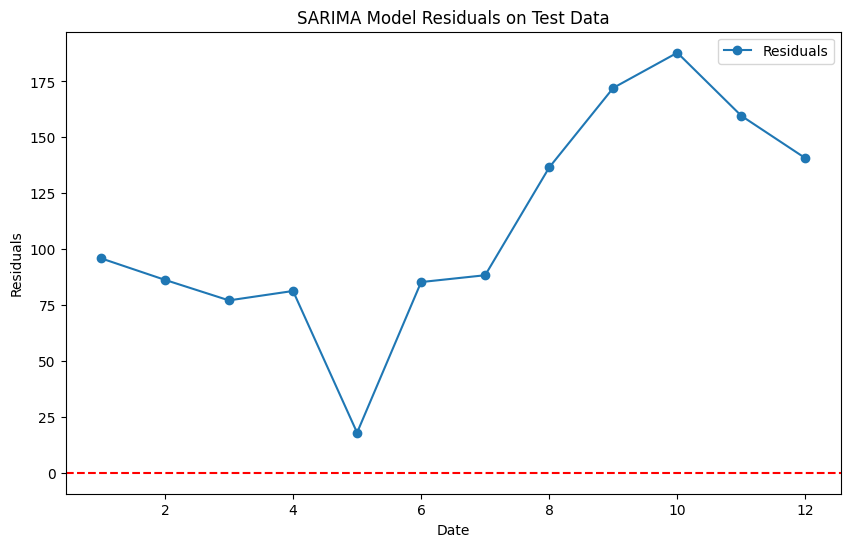

In [53]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Разделяем данные: все кроме последних 12 наблюдений для обучения, последние 12 для тестирования
train = df['Total Crimes'][:-12]
test = df['Total Crimes'][-12:]

# Строим и обучаем модель SARIMA с учетом сезонности (период=12)
model_sarima = SARIMAX(train, order=(1, 1, 1), seasonal_order=(1, 1, 1, 12))
model_fit_sarima = model_sarima.fit()

# Делаем прогноз на тестовый период (12 шагов вперёд)
forecast = model_fit_sarima.get_forecast(steps=12)
predictions = forecast.predicted_mean

# Вычисляем остатки: разница между фактическими значениями и прогнозом
residuals = test - predictions

# Собираем данные в DataFrame для визуализации
df_residuals = pd.DataFrame({
    'Actual': test,
    'Predicted': predictions,
    'Residuals': residuals
})
df_residuals.index = df_residuals.reindex([i for i in range(1, 13)]).index
print(df_residuals)

# Построение графика остатков по датам
plt.figure(figsize=(10, 6))
plt.plot(df_residuals.index, df_residuals['Residuals'], marker='o', linestyle='-', label='Residuals')
plt.axhline(0, color='red', linestyle='--')  # горизонтальная линия на уровне 0
plt.xlabel('Date')
plt.ylabel('Residuals')
plt.title('SARIMA Model Residuals on Test Data')
plt.legend()
plt.show()

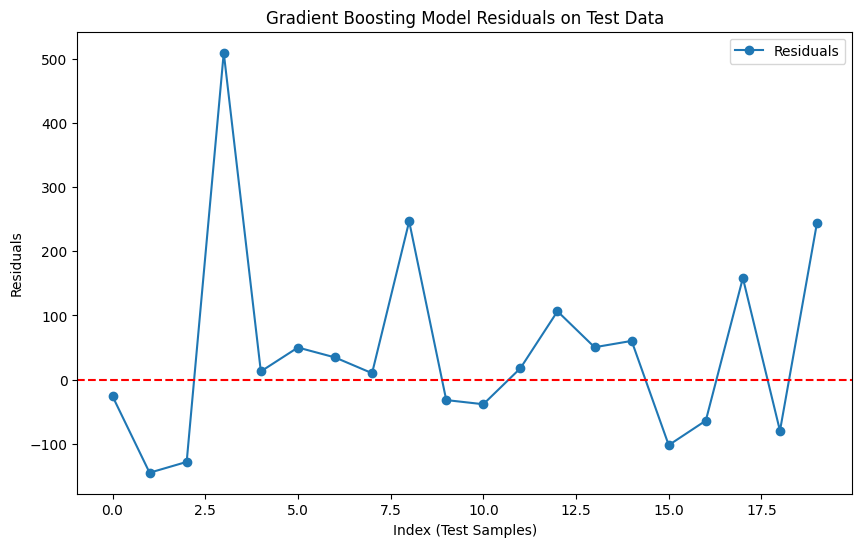

In [69]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import train_test_split

# Допустим, у вас есть исходный DataFrame df с нужными текстовыми и числовыми колонками
# Предположим, что df['Date'] и df['Total Crimes'] уже существуют

# 1) Создаём агрегированные признаки
df_agg = pd.DataFrame()

df_agg['Corruption_Sum'] = df[['corruption', 'bribe', 'verdict', 'embezzlement', 'investigation']].sum(axis=1)
df_agg['Detentions_Sum'] = df['detention']
df_agg['Finance_Sum'] = df[['dollar', 'million', 'billion']].sum(axis=1)
df_agg['Authorities_Sum'] = df[['agency', 'ministry', 'akim', 'chief', 'deputy', 'district', 'city', 'region']].sum(axis=1)
df_agg['Offenses_Sum'] = df[['crime', 'offense', 'court']].sum(axis=1)

# Добавляем компоненты времени
df_agg['Month'] = pd.to_datetime(df['Date']).dt.month
df_agg['Year'] = pd.to_datetime(df['Date']).dt.year

# Целевая переменная
df_agg['Total Crimes'] = df['Total Crimes']

# 2) Подготовка данных для обучения
df_gbr = df_agg.copy()

X = df_gbr.drop(columns=["Total Crimes"])
y = df_gbr["Total Crimes"]

# Если хотите сохранить дату для анализа остатков по времени, можно:
# df_gbr['Date'] = pd.to_datetime(df['Date'])
# X = df_gbr.drop(columns=["Total Crimes"])
# И потом при необходимости объединить X_test и y_test через индексы

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=13
)

# 3) Обучаем модель градиентного бустинга
model_gbr = GradientBoostingRegressor(n_estimators=100, random_state=13)
model_fit_gbr = model_gbr.fit(X_train, y_train)

# 4) Делаем предсказания на тестовой выборке
y_pred = model_fit_gbr.predict(X_test)

# 5) Формируем DataFrame с фактическими и предсказанными значениями
df_residuals = pd.DataFrame({
    'Actual': y_test,
    'Predicted': y_pred
})

# 6) Вычисляем остатки
df_residuals['Residuals'] = df_residuals['Actual'] - df_residuals['Predicted']

# Если хотите проиндексировать заново с 1 до N:
df_residuals.reset_index(drop=True, inplace=True)

# 7) Строим график остатков
plt.figure(figsize=(10, 6))
plt.plot(df_residuals.index, df_residuals['Residuals'], marker='o', linestyle='-', label='Residuals')
plt.axhline(0, color='red', linestyle='--')  # Линия y=0
plt.xlabel('Index (Test Samples)')
plt.ylabel('Residuals')
plt.title('Gradient Boosting Model Residuals on Test Data')
plt.legend()
plt.show()
